# Ablative Study - EfficientNet B2
Brain MRI classification trained on 3 datasets using EfficientNet-B2 (untrained weights).

## 1. Setup

In [25]:
#Install Dependencies
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 --upgrade --quiet
!pip install numpy pandas matplotlib seaborn scikit-learn torchmetrics grad-cam --quiet

In [26]:
import copy, time, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchmetrics import Accuracy, Precision, Recall, F1Score
from sklearn.metrics import classification_report, confusion_matrix
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

try:
    from google.colab import drive
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Device setup
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    torch.backends.cudnn.benchmark = True   # optimise conv for fixed input sizes
    torch.backends.cudnn.deterministic = False  # faster, fine for training
    gpu = torch.cuda.get_device_properties(0)
    print(f'Using GPU : {gpu.name}  ({gpu.total_memory / 1024**3:.1f} GB VRAM)')
else:
    DEVICE = torch.device('cpu')
    print('No CUDA GPU found — running on CPU')

print(f'PyTorch   : {torch.__version__}')
print(f'CUDA      : {torch.version.cuda}')
print(f'Running on: {"Google Colab" if ON_COLAB else "local environment"}')

Using GPU : NVIDIA GeForce RTX 4050 Laptop GPU  (6.0 GB VRAM)
PyTorch   : 2.10.0+cu126
CUDA      : 12.6
Running on: local environment


In [27]:
if ON_COLAB:
    drive.mount('/content/drive')
    OUTPUT_DIR = Path('/content/drive/MyDrive/COMP472/outputs/efficientnet_b2')
    preprocessed_dir = '/content/drive/MyDrive/brain_mri_preprocessed'
else:
    #  Local paths 
    OUTPUT_DIR       = Path('./outputs/efficientnet_b2')
    preprocessed_dir = './brain_mri_preprocessed'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output directory : {OUTPUT_DIR}')
print(f'Preprocessed data: {preprocessed_dir}')

Output directory : outputs\efficientnet_b2
Preprocessed data: ./brain_mri_preprocessed


## 2. Default Training Hyperparameters

In [28]:
BATCH_SIZE    = 32
NUM_EPOCHS    = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
IMG_SIZE      = 224

## 3. Data

Images have been preprocessed to grayscale, tensors of 224×224 and normalized 0–255 → [0, 1].

### 3.1 Load Datasets

In [29]:
from torch.utils.data import DataLoader

# Dataset 3 : 4,478 images  15 classes 
train_data_ds3 = torch.load(f'{preprocessed_dir}/dataset3_train.pt')
val_data_ds3   = torch.load(f'{preprocessed_dir}/dataset3_val.pt')
test_data_ds3  = torch.load(f'{preprocessed_dir}/dataset3_test.pt')

train_images_ds3 = train_data_ds3['images']
train_labels_ds3 = train_data_ds3['labels']
val_images_ds3   = val_data_ds3['images']
val_labels_ds3   = val_data_ds3['labels']
test_images_ds3  = test_data_ds3['images']
test_labels_ds3  = test_data_ds3['labels']
class_names_ds3  = list(train_data_ds3['class_to_label'].keys())

### 3.2 Data Augmentation

MONAI transforms are applied on-the-fly during training only.

In [30]:
!pip install monai --quiet

In [31]:
import logging, os, sys, tempfile
from monai.transforms import (
    Compose,
    RandRotate,
    RandZoom,
    RandGaussianNoise,
    RandAdjustContrast,
    RandShiftIntensity,
)


class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


def get_train_transforms():
    return Compose([
        RandRotate(range_x=0.15, prob=0.5, keep_size=True),
        RandZoom(min_zoom=0.95, max_zoom=1.05, prob=0.3, keep_size=True),
        RandGaussianNoise(mean=0.0, std=0.01, prob=0.2),
        RandAdjustContrast(gamma=(0.9, 1.1), prob=0.2),
        RandShiftIntensity(offsets=0.05, prob=0.2),
    ])


# Dataset 3
train_dataset_ds3 = AugmentedDataset(train_images_ds3, train_labels_ds3, transform=get_train_transforms())
val_dataset_ds3   = AugmentedDataset(val_images_ds3,   val_labels_ds3,   transform=None)
test_dataset_ds3  = AugmentedDataset(test_images_ds3,  test_labels_ds3,  transform=None)

print('Augmented datasets ready')

Augmented datasets ready


### 3.3 DataLoaders

In [32]:

#  Dataset 3 
train_loader_ds3 = DataLoader(train_dataset_ds3, batch_size=BATCH_SIZE, shuffle=True)
val_loader_ds3   = DataLoader(val_dataset_ds3,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_ds3  = DataLoader(test_dataset_ds3,  batch_size=BATCH_SIZE, shuffle=False)

num_classes_ds3 = len(class_names_ds3)
print(f'DS3  Train: {len(train_dataset_ds3):,}  Val: {len(val_dataset_ds3):,}  Test: {len(test_dataset_ds3):,}  Classes: {num_classes_ds3}')
print(f'Class names: {class_names_ds3}')

#  DO NOT EDIT BELOW 
DATASETS = [
    {
        'name': f'Dataset 3 — Brain Tumor MRI Images ({num_classes_ds3} merged classes)',
        'num_classes': num_classes_ds3, 'class_names': class_names_ds3,
        'train_loader': train_loader_ds3, 'val_loader': val_loader_ds3, 'test_loader': test_loader_ds3,
    },
]
print('Dataset config ready')

DS3  Train: 3,134  Val: 447  Test: 897  Classes: 15
Class names: ['Astrocitoma', 'Carcinoma', 'Ependimoma', 'Ganglioglioma', 'Germinoma', 'Glioblastoma', 'Granuloma', 'Meduloblastoma', 'Meningioma', 'Neurocitoma', 'Oligodendroglioma', 'Papiloma', 'Schwannoma', 'Tuberculoma', '_NORMAL']
Dataset config ready


## 4. Model — EfficientNet B2

- Input channel modified: 3 to 1 (grayscale MRI)
- Classifier head replaced to match `num_classes` (4 or 44)
- Weights: random init (no pretrained weights)

In [33]:
def build_efficientNet_b2(num_classes: int) -> nn.Module:
    model = models.efficientnet_b2(weights=None)
    # Replace first conv to accept 1-channel (grayscale) input
    model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
    # Replace classifier head
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model.to(DEVICE)


# Sanity check
_m = build_efficientNet_b2(4)
_x = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
print(f'Output shape    : {list(_m(_x).shape)}')
print(f'Trainable params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
print(_m.features[0][0])
del _m, _x

Output shape    : [2, 4]
Trainable params: 7,706,054
Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)


## 5. Training & Evaluation Functions

In [34]:
def train_one_epoch(model, loader, criterion, optimizer, num_classes):
    model.train()
    loss_sum = 0.0
    acc_m = Accuracy(task='multiclass', num_classes=num_classes).to(DEVICE)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        acc_m.update(out.argmax(1), labels)
    return loss_sum / len(loader.dataset), acc_m.compute().item()


@torch.no_grad()
def evaluate(model, loader, criterion, num_classes):
    model.eval()
    loss_sum = 0.0
    acc_m = Accuracy(task='multiclass', num_classes=num_classes).to(DEVICE)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        loss_sum += criterion(out, labels).item() * imgs.size(0)
        acc_m.update(out.argmax(1), labels)
    return loss_sum / len(loader.dataset), acc_m.compute().item()


@torch.no_grad()
def full_evaluation(model, loader, num_classes, class_names):
    model.eval()
    all_preds, all_labels = [], []
    ms = {
        'acc':  Accuracy( task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
        'prec': Precision(task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
        'rec':  Recall(   task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
        'f1':   F1Score(  task='multiclass', num_classes=num_classes, average='macro').to(DEVICE),
    }
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(1)
        for m in ms.values(): m.update(preds, labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    results = {k: v.compute().item() for k, v in ms.items()}
    results.update({'all_preds': all_preds, 'all_labels': all_labels})

    print(f"  Accuracy : {results['acc']:.4f}")
    print(f"  Precision: {results['prec']:.4f}")
    print(f"  Recall   : {results['rec']:.4f}")
    print(f"  F1-Score : {results['f1']:.4f}")
    print(classification_report(all_labels, all_preds,
          target_names=(class_names if len(class_names) <= 20 else None), digits=4))
    return results


def train_model(model, cfg, save_path):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val, best_w = float('inf'), None
    nc = cfg['num_classes']

    for ep in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, cfg['train_loader'], criterion, optimizer, nc)
        vl, va = evaluate(model, cfg['val_loader'], criterion, nc)
        scheduler.step(vl)
        for k, v in zip(history, [tl, vl, ta, va]): history[k].append(v)
        flag = ''
        if vl < best_val:
            best_val, best_w = vl, copy.deepcopy(model.state_dict())
            torch.save(best_w, save_path)
            flag = ' ✅'
        print(f'Ep [{ep:>2}/{NUM_EPOCHS}] Train {tl:.4f}/{ta:.4f} | Val {vl:.4f}/{va:.4f} | {time.time()-t0:.1f}s{flag}')

    model.load_state_dict(best_w)
    return model, history


print('Training & evaluation functions ready')

Training & evaluation functions ready


## 6. Visualization Functions

In [35]:
def plot_curves(history, name, save_path):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'EfficientNet B2 — {name}', fontweight='bold')
    for ax, key, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
        ax.plot(epochs, history[f'train_{key}'], 'b-o', ms=4, label='Train')
        ax.plot(epochs, history[f'val_{key}'],   'r-o', ms=4, label='Val')
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
        if key == 'acc': ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()


def plot_confusion_matrix(results, class_names, name, save_path):
    cm = confusion_matrix(results['all_labels'], results['all_preds'], normalize='true')
    n  = len(class_names)
    fig, ax = plt.subplots(figsize=(min(n*0.7+2, 20), min(n*0.6+2, 18)))
    sns.heatmap(cm, annot=(n <= 15), fmt=('.2f' if n <= 15 else ''), cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right', fontsize=(8 if n > 15 else 10))
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()


def plot_grad_cam(model, loader, class_names, name, save_path, n=8):
    model.eval()
    cam = GradCAM(model=model, target_layers=[model.features[-1]])
    imgs, labels = next(iter(loader))
    imgs = imgs[:n].to(DEVICE)
    with torch.no_grad():
        preds = model(imgs).argmax(1).cpu()
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    fig, axes = plt.subplots(2, n // 2, figsize=(n * 2, 8))
    fig.suptitle(f'Grad-CAM — {name}', fontweight='bold')
    for i, ax in enumerate(axes.flatten()):
        gc = cam(input_tensor=imgs[i:i+1], targets=[ClassifierOutputTarget(preds[i].item())])[0]
        img_np = np.clip(std * imgs[i].cpu().numpy().transpose(1, 2, 0) + mean, 0, 1).astype(np.float32)
        ax.imshow(show_cam_on_image(img_np, gc, use_rgb=True))
        ax.set_title(f'True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}',
                     color=('green' if preds[i] == labels[i] else 'red'), fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()


print('Visualization functions ready')

Visualization functions ready


## 7. Train on Dataset 3 with merged labels 


  Dataset 1/3: Dataset 3 — Brain Tumor MRI Images (15 merged classes)
  Classes: 15
Ep [ 1/20] Train 2.5817/0.1844 | Val 2.4799/0.1991 | 107.3s ✅
Ep [ 2/20] Train 2.4360/0.1959 | Val 2.3445/0.2550 | 100.2s ✅
Ep [ 3/20] Train 2.3199/0.2540 | Val 2.1637/0.2998 | 97.6s ✅
Ep [ 4/20] Train 2.2019/0.2843 | Val 2.0452/0.3244 | 99.6s ✅
Ep [ 5/20] Train 2.0560/0.3350 | Val 1.8925/0.3870 | 100.5s ✅
Ep [ 6/20] Train 1.9117/0.3854 | Val 1.8220/0.4116 | 101.5s ✅
Ep [ 7/20] Train 1.7773/0.4266 | Val 1.6566/0.4452 | 100.4s ✅
Ep [ 8/20] Train 1.6511/0.4684 | Val 1.5832/0.5123 | 100.7s ✅
Ep [ 9/20] Train 1.5609/0.5026 | Val 1.4858/0.5660 | 100.7s ✅
Ep [10/20] Train 1.4428/0.5447 | Val 1.3169/0.5570 | 101.1s ✅
Ep [11/20] Train 1.3406/0.5638 | Val 1.2210/0.6398 | 102.5s ✅
Ep [12/20] Train 1.2416/0.6091 | Val 1.1162/0.6555 | 101.8s ✅
Ep [13/20] Train 1.1219/0.6455 | Val 0.9759/0.7092 | 102.5s ✅
Ep [14/20] Train 1.0458/0.6701 | Val 0.9121/0.7136 | 97.2s ✅
Ep [15/20] Train 0.9549/0.6981 | Val 1.0074/0.7025

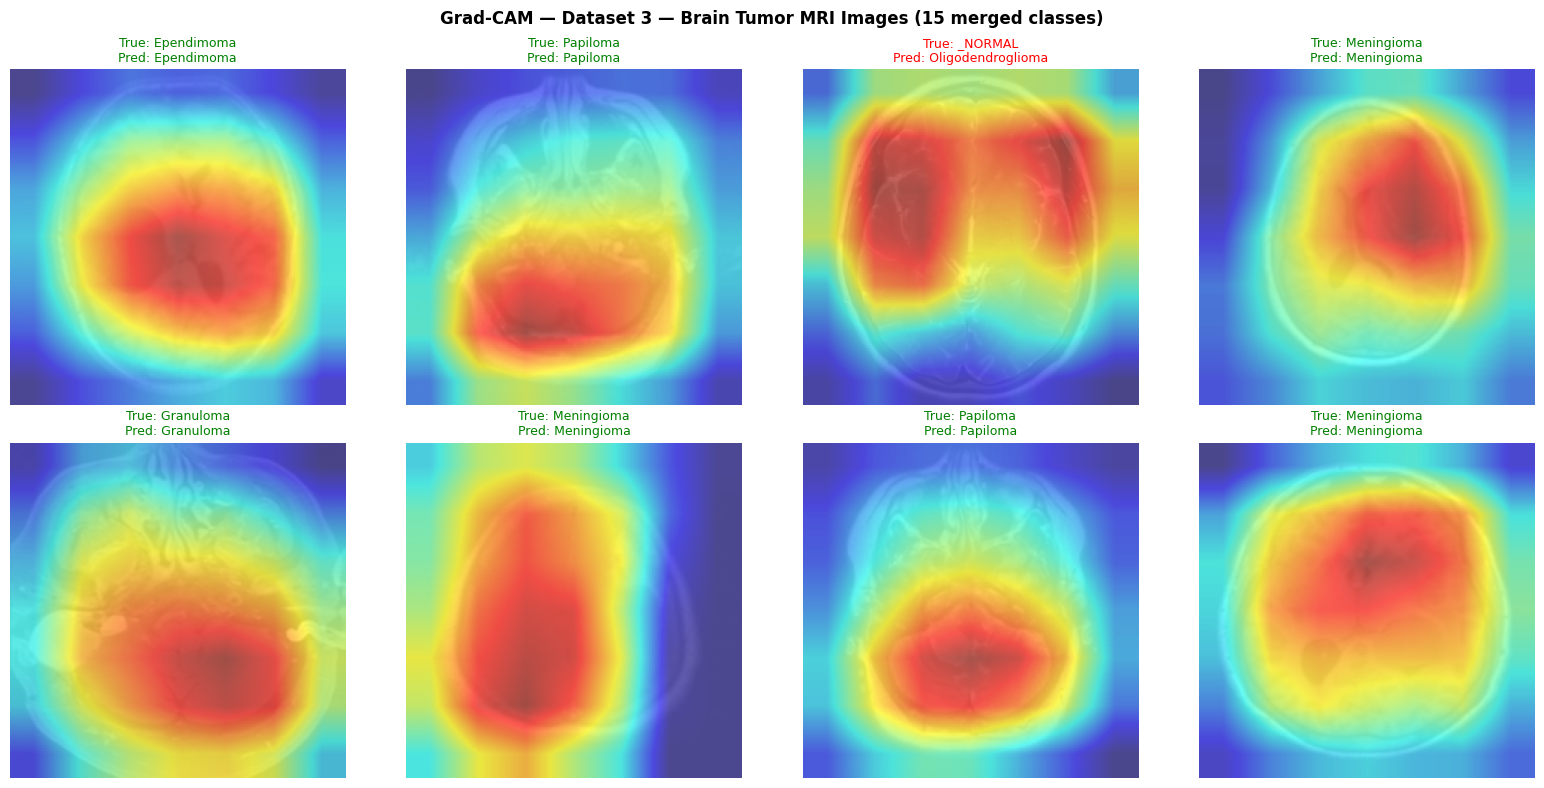


All datasets trained!


In [36]:
all_results   = {}
all_histories = {}

for i, cfg in enumerate(DATASETS, start=1):
    print(f'\n{"="*55}\n  Dataset {i}/1: {cfg["name"]}\n  Classes: {cfg["num_classes"]}\n{"="*55}')

    model = build_efficientNet_b2(cfg['num_classes'])
    ckpt  = OUTPUT_DIR / f'efficientNet_b2_dataset{i}_best.pth'
    model, history = train_model(model, cfg, ckpt)

    # Overfitting gap per epoch 
    print('\n Overfitting Gap (Train Acc - Val Acc) per epoch ')
    print(f'  {"Epoch":<8} {"Train Acc":>10} {"Val Acc":>10} {"Gap %":>8} {"Status":>12}')
    print(f'  {"-"*50}')
    for ep, (tr, vl) in enumerate(zip(history['train_acc'], history['val_acc']), start=1):
        gap    = tr - vl
        status = '⚠ Overfit' if gap > 0.15 else ('⚠ Underfit' if tr < 0.60 and vl < 0.60 else '✓ OK')
        print(f'  {ep:<8} {tr*100:>9.1f}% {vl*100:>9.1f}% {gap*100:>7.1f}% {status:>12}')

    final_gap = history['train_acc'][-1] - history['val_acc'][-1]
    print(f'\n  Final gap: {final_gap*100:.1f}%')

    #  Test evaluation
    print('\ Test Results ')
    results = full_evaluation(model, cfg['test_loader'], cfg['num_classes'], cfg['class_names'])
    all_results[cfg['name']]   = results
    all_histories[cfg['name']] = history

    # Val vs Test generalisation check
    best_val_acc = max(history['val_acc'])
    print(f'\ Generalisation Check ')
    print(f'  Best Val Accuracy  : {best_val_acc*100:.2f}%')
    print(f'  Test Accuracy      : {results["acc"]*100:.2f}%')
    print(f'  Gap                : {(best_val_acc - results["acc"])*100:.2f}%')
    if abs(best_val_acc - results["acc"]) > 0.05:
        print('  ⚠ Large gap between val and test — model may not generalise well')
    else:
        print('  ✓ Val and test accuracy are close — good generalisation')

    # Grad-CAM must run before the model is deleted
    plot_grad_cam(model, cfg['test_loader'], cfg['class_names'], cfg['name'],
                  OUTPUT_DIR / f'efficientNet_b2_dataset{i}_gradcam.png')

    del model; torch.cuda.empty_cache()

print('\nAll datasets trained!')


── Plots: Dataset 3 — Brain Tumor MRI Images (15 merged classes) ──


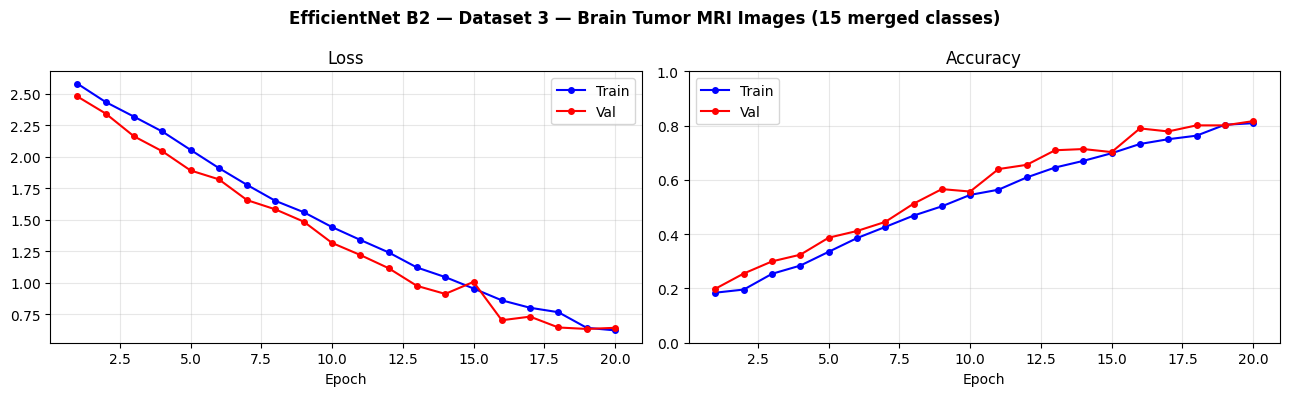

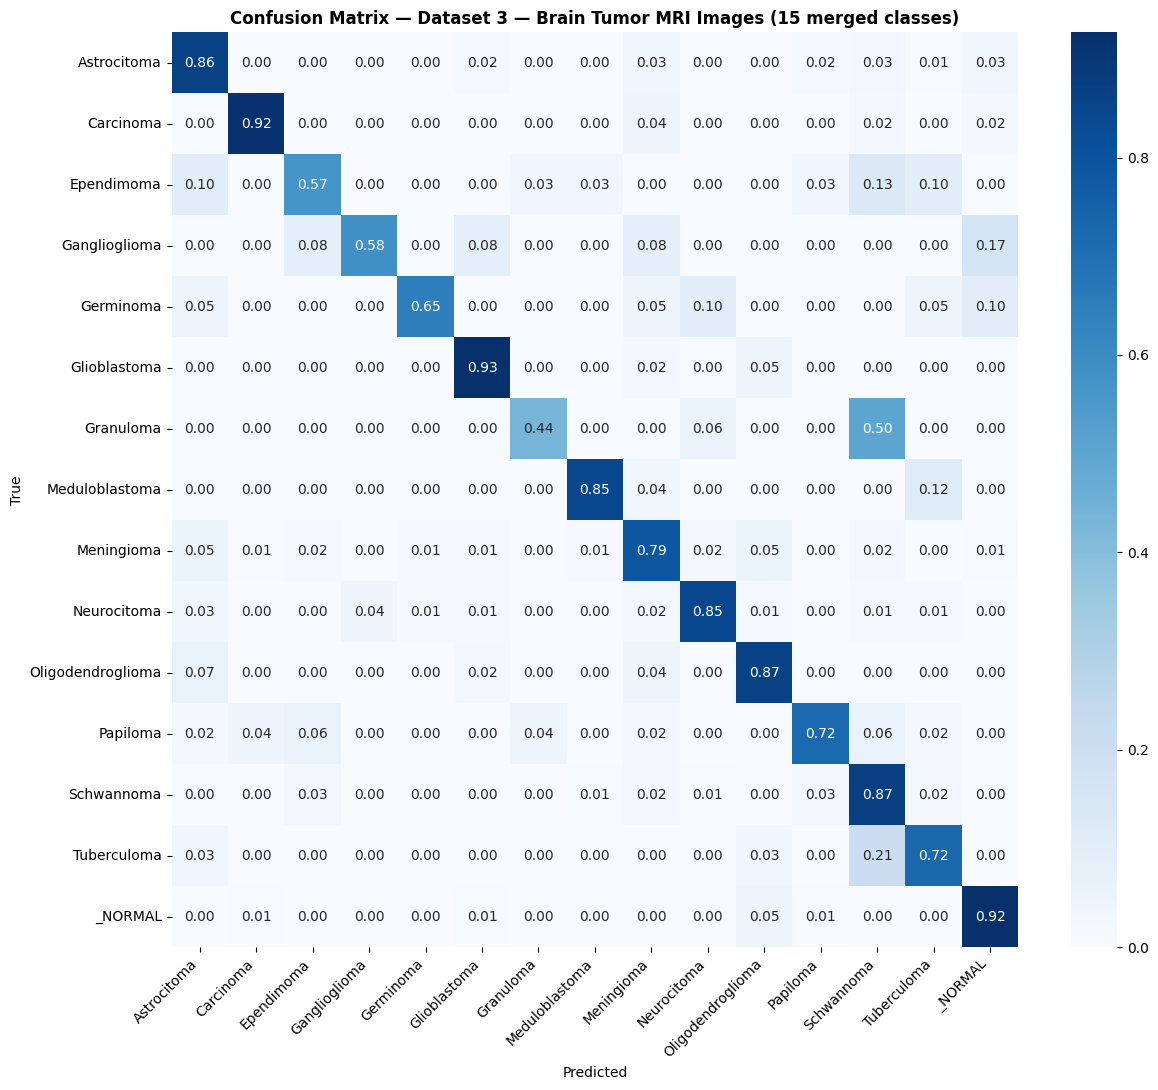

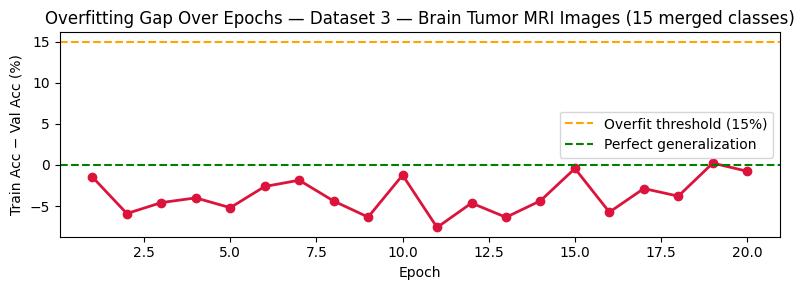


All plots saved!


In [37]:
for i, cfg in enumerate(DATASETS, start=1):
    name    = cfg['name']
    history = all_histories[name]
    results = all_results[name]

    print(f'\n── Plots: {name} ──')
    plot_curves(history, name,
                OUTPUT_DIR / f'efficientNet_b2_dataset{i}_curves.png')
    plot_confusion_matrix(results, cfg['class_names'], name,
                OUTPUT_DIR / f'efficientNet_b2_dataset{i}_confusion.png')

    # Overfitting summary plot
    epochs = range(1, len(history['train_acc']) + 1)
    gaps   = [(tr - vl) * 100 for tr, vl in zip(history['train_acc'], history['val_acc'])]
    plt.figure(figsize=(8, 3))
    plt.plot(epochs, gaps, marker='o', color='crimson', linewidth=2)
    plt.axhline(y=15, color='orange', linestyle='--', label='Overfit threshold (15%)')
    plt.axhline(y=0,  color='green',  linestyle='--', label='Perfect generalization')
    plt.fill_between(epochs, gaps, 0, where=[g > 0 for g in gaps], alpha=0.15, color='crimson')
    plt.title(f'Overfitting Gap Over Epochs — {name}')
    plt.xlabel('Epoch'); plt.ylabel('Train Acc − Val Acc (%)')
    plt.legend(); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'efficientNet_b2_dataset{i}_gap.png', dpi=150)
    plt.show()

print('\nAll plots saved!')

## 8. Results Summary

In [38]:
import json
print("EfficientNet B2 _ Datase3 Classes merged")
rows = [
    {
        'Dataset':       name,
        'Model':         'EfficientNet B2 (untrained)',
        'Batch_Size':    BATCH_SIZE,
        'Epochs':        NUM_EPOCHS,
        'Learning_Rate': LEARNING_RATE,
        'Weight_Decay':  WEIGHT_DECAY,
        'Image_Size':    IMG_SIZE,
        'Accuracy':      f"{r['acc']:.4f}",
        'Precision':     f"{r['prec']:.4f}",
        'Recall':        f"{r['rec']:.4f}",
        'F1-Score':      f"{r['f1']:.4f}",
    }
    for name, r in all_results.items()
]

df = pd.DataFrame(rows, index=[f'Dataset {i+1}' for i in range(len(rows))])
print(df.to_string())
df.to_csv(OUTPUT_DIR / 'efficientnet_b2_results_dataset3merged.csv')
print(f'\nSaved to {OUTPUT_DIR}/efficientnet_b2_results_dataset3merge.csv')

# Save per-dataset training history
for name, history in all_histories.items():
    safe_name    = name.replace(' ', '_').replace('—', '-')
    history_path = OUTPUT_DIR / f'{safe_name}_history.json'
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f'Saved history: {history_path}')

EfficientNet B2 _ Datase3 Classes merged
                                                          Dataset                        Model  Batch_Size  Epochs  Learning_Rate  Weight_Decay  Image_Size Accuracy Precision  Recall F1-Score
Dataset 1  Dataset 3 — Brain Tumor MRI Images (15 merged classes)  EfficientNet B2 (untrained)          32      20         0.0001        0.0001         224   0.7692    0.7855  0.7692   0.7725

Saved to outputs\efficientnet_b2/efficientnet_b2_results_dataset3merge.csv
Saved history: outputs\efficientnet_b2\Dataset_3_-_Brain_Tumor_MRI_Images_(15_merged_classes)_history.json
